#### Programa15.Clasificacion.LOGR

![TextoAlternativo](logoitqv1.jpg)

#### 0.1 PAO25-25- REGRESIÓN LOGISTICA

![Texto Alternativo](python_logo.png)

* Nombre: Martin Sosa
* Fecha:  **13-07-2026**
* Repositorio: <a href="https://github.com/Martin122334/machine2026nocturno">Link del repositorio de Github</a>

In [109]:
import pandas as pd
def evaluacion(y_true, y_pred, metricas):
    "Calcula un diccionario o DataFrame con las métricas pasadas para la evaluación."
    resultados = {}
    for nombre, metrica in metricas.items():
        resultados[nombre] = metrica(y_true, y_pred)

    return pd.DataFrame(resultados, index=["Valor"])

In [110]:
import matplotlib.pyplot as plt
import numpy as np

def mapa_modelo_clasif_2d(X, y, model, results=None, nombre=""):
    "Dibuja el mapa de fronteras de decisión en 2D para un modelo de clasificación."
    h = 0.02  # Paso de la malla
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(
        X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k", s=40
    )
    plt.title(f"Fronteras de decisión - {nombre}")
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.show()

In [111]:
import sklearn.metrics as metrics
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, train_test_split, KFold
from sklearn import preprocessing

In [112]:
# Carga de datos.
datos = load_iris()
X = datos.data[:,2:] # Utilizamos solo 2 atributos.
y = datos.target

In [113]:
print(np.shape(X))

(150, 2)


In [114]:
# Métricas de evaluación.
metricas = {
'ACC': metrics.accuracy_score,
'PREC': lambda y_true, y_pred:
metrics.precision_score(y_true, y_pred, average='micro'),
'RECALL': lambda y_true, y_pred:
metrics.recall_score(y_true, y_pred, average='micro'),
'F1': lambda y_true, y_pred:
metrics.f1_score(y_true, y_pred, average='micro')}

In [115]:
# 1) Partición de datos externa
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_training))

(120, 2)


In [116]:
# ------------- TRAINING ---------------- #

In [117]:
# 2) Extracción de características

In [118]:
# 3) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
X_stdr = standardizer.fit_transform(X_training)
print(X_stdr)

[[-1.56253475 -1.31260282]
 [-1.27600637 -1.04563275]
 [ 0.38585821  0.28921757]
 [-1.2187007  -1.31260282]
 [-1.39061772 -1.31260282]
 [ 0.72969227  0.95664273]
 [ 0.44316389  0.4227026 ]
 [-1.27600637 -1.31260282]
 [-1.33331205 -1.31260282]
 [-1.27600637 -1.44608785]
 [ 0.78699794  0.95664273]
 [ 0.44316389  0.55618763]
 [ 0.55777524  0.4227026 ]
 [-1.39061772 -1.04563275]
 [-1.27600637 -1.31260282]
 [-0.01528151 -0.24472256]
 [ 0.78699794  0.4227026 ]
 [ 1.01622064  0.8231577 ]
 [ 0.38585821  0.28921757]
 [ 1.3600547   1.75755292]
 [ 0.27124686  0.15573254]
 [ 1.64658307  1.22361279]
 [ 0.44316389  0.4227026 ]
 [-1.33331205 -1.31260282]
 [ 1.70388875  1.09012776]
 [ 0.21394119 -0.24472256]
 [-1.33331205 -1.31260282]
 [-1.39061772 -1.17911778]
 [-1.04678367 -1.04563275]
 [-0.12989286 -0.24472256]
 [ 0.67238659  0.8231577 ]
 [-1.04678367 -1.31260282]
 [-1.2187007  -1.31260282]
 [-1.16139502 -0.91214772]
 [ 0.27124686  0.15573254]
 [-1.27600637 -1.31260282]
 [ 0.27124686  0.02224751]
 

In [119]:
# 4) Selección de atributos

In [120]:
# Sintaxis moderna sin 'penalty' para evitar el FutureWarning
algoritmos = {"LOGR": LogisticRegression(l1_ratio=1.0, solver="saga",max_iter=1000,random_state=42,)}

In [121]:
# 5.1) Validación cruzada interna y Optimización de hiperparámetros
y_pred = {}

for nombre, alg in algoritmos.items():
    # Predicción mediante validación cruzada
    y_pred[nombre] = cross_val_predict(
        alg,
        X_stdr,
        y_training,
        cv=KFold(n_splits=10, shuffle=True, random_state=42),
    )
    print(f"=== Reporte para {nombre} ===")
    print(metrics.classification_report(y_training, y_pred[nombre]))
    print("Matriz de confusión:")
    print(metrics.confusion_matrix(y_training, y_pred[nombre]))

    results = cross_val_score(
        alg,
        X_stdr,
        y_training,
        cv=KFold(n_splits=10, shuffle=True, random_state=42),
    )
    print("Accuracy: %0.4f +/- %0.4f" % (results.mean(), results.std()))

=== Reporte para LOGR ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.90      0.93      0.92        41
           2       0.92      0.90      0.91        39

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120

Matriz de confusión:
[[40  0  0]
 [ 0 38  3]
 [ 0  4 35]]
Accuracy: 0.9417 +/- 0.0750


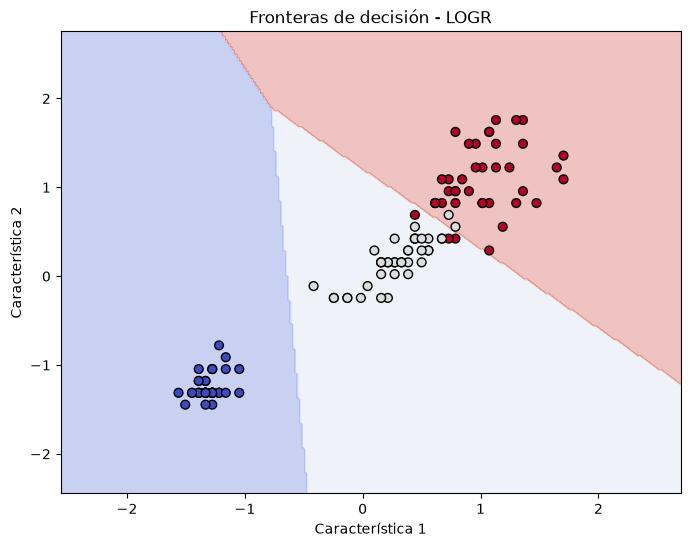

In [122]:
# 5.2) Entrenamiento del modelo definitivo
model = algoritmos['LOGR'].fit(X_stdr, y_training)
# Visualización de las fronteras de decisión
mapa_modelo_clasif_2d(X_stdr, y_training, model, results, nombre)

In [123]:
# ------------- PREDICTION ---------------- #

In [124]:
# 6) Extracción de las características de test

In [125]:
# 7) Estandarización de las característiacs de test
X_test_stdr = standardizer.transform(X_testing)

In [126]:
# 8) Selección de los atributos de test

In [127]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)
print(y_pred_test)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [128]:
# 10) Evaluación del modelo sobre el conjunto de test
results = evaluacion(y_testing, y_pred_test, metricas)
print(results)
print(metrics.confusion_matrix(y_testing, y_pred_test))

       ACC  PREC  RECALL   F1
Valor  1.0   1.0     1.0  1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


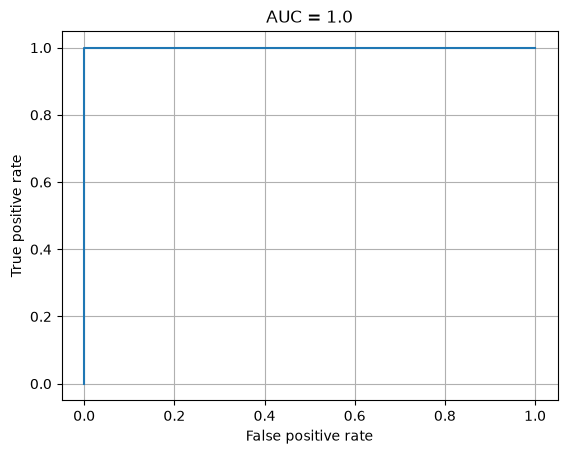

In [129]:
# Ploteamos la curva ROC
y_proba_test = model.predict_proba(X_test_stdr) # "predict_proba" para extraer probabilidades vez de predicciones
y_test_bin = preprocessing.label_binarize(y_testing, classes=[0,1,2]) # Usar "label_binarize" en el caso de problemas multiclase
auc = metrics.roc_auc_score(y_testing, y_proba_test, multi_class='ovr') # Area Under the ROC curve (AUC)
fpr, tpr, th = metrics.roc_curve(y_test_bin[:,1], y_proba_test[:,1])
plt.plot(fpr, tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('AUC = ' + str(np.round(auc,4)))
plt.grid()
plt.show()